**Project #3**

In [2]:
import matplotlib.pyplot as plt
import numpy as np
#from google.colab import files

If we want to save our data to google drive, we have to connect our Python notebook to our google drive account! Running this will ask us to confirm that we want this notebook to be able to access drive. This will also make a folder called 'Python4Physics' in your google drive

In [3]:
#from google.colab import drive
#drive.mount('/content/drive')
#!mkdir -p "/content/drive/My Drive/Python4Physics"
#filepath="drive/My Drive/Python4Physics/"

Mounted at /content/drive


Make sure you've created a copy of this notebook and the provided data file 'pBs_2body_decay.txt' in your Python4Physics folder.

In [11]:
import os
print(os.getcwd())

/home/d2ef8ae0-4d22-4704-bf96-a4028e3ad1d9/REYES-STEM/Day_4


In [4]:
# Let's get our data!
filename = 'pBs_2body_decay.txt'
q0s = np.loadtxt('pBs_2body_decay.txt')
const_data = np.loadtxt('const_data.txt')
print("q0s = ", q0s[0:10])
print("type(q0s) = ", type(q0s))
print("shape(q0s) = ", np.shape(q0s))
print(const_data)

# These q0s are our momentum measurements

q0s =  [0.7338822  0.73414999 0.73213688 0.73275698 0.73319379 0.73484167
 0.73355556 0.73283873 0.73216609 0.73458736]
type(q0s) =  <class 'numpy.ndarray'>
shape(q0s) =  (1000,)
[[0.00000000e+00 9.99560807e+02 2.01088086e+00]
 [1.00000000e+00 9.98900030e+02 1.63579559e+00]
 [2.00000000e+00 9.99006022e+02 2.19626949e+00]
 [3.00000000e+00 1.00114502e+03 2.72774801e+00]
 [4.00000000e+00 1.00032573e+03 3.13391002e+00]
 [5.00000000e+00 9.99696697e+02 2.58235211e+00]
 [6.00000000e+00 1.00118586e+03 3.61013216e+00]
 [7.00000000e+00 9.98864262e+02 3.99005336e+00]
 [8.00000000e+00 1.00043714e+03 4.13895104e+00]
 [9.00000000e+00 9.99712177e+02 4.06540222e+00]
 [1.00000000e+01 9.99827026e+02 4.06572785e+00]
 [1.10000000e+01 1.00096587e+03 4.41814842e+00]
 [1.20000000e+01 9.99546236e+02 2.08626078e+00]
 [1.30000000e+01 9.99827716e+02 4.19140934e+00]
 [1.40000000e+01 9.99739141e+02 2.86803636e+00]
 [1.50000000e+01 9.99699786e+02 3.10058175e+00]
 [1.60000000e+01 9.99448847e+02 4.00191682e+00]
 [1.7

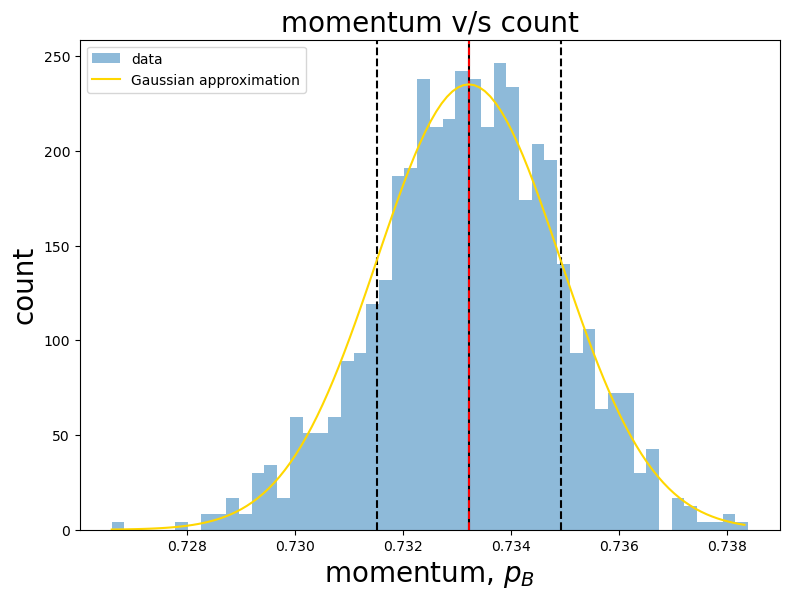

In [5]:
# let us make a figure using the axes class
# first, we create a new figure; we will also learn about multi-line comments created with ''' or """
# Matplotlib user guide: https://matplotlib.org/stable/users/index.html
fig = plt.figure(figsize = (10,7))
''' next, we create a axes canvas.  The 4 numbers represent
    ax = plt.axes([x0, y0, dx, dy])
    - x0: width from left to start canvas (in units of 0 - 1)
    - y0: height from bottome to start canvas
    - dx: width of canvas - NOTE, x0 + dx <= 1
    - dy: height of canvas - NOTE, y0 + dy <= 1
'''

ax = plt.axes([0.3, 0.3, 0.7, 0.7])

''' Now let us plot the histogram
    - Nbins  : the number of bins to use
    - alpha  : a parameter taking the value [0, 1] that controls opacity
    - ;      : the semi-colon at the end prevents the function from printing
               values of the histogram - try removing it
    - density: if True, it will normalize so that int(hist) = 1

'''

Nbins = 50
ax.hist(q0s, bins=Nbins, alpha=.5, density=True, label='data');

# let us make some axis labels
ax.set_ylabel(r'count', fontsize=20);
ax.set_xlabel(r'momentum, $p_B$', fontsize=20);

# plot the mean value
ax.axvline(q0s.mean(), color='k')
# plot the standard deviation
ax.axvline(q0s.mean()-q0s.std(), color='k', linestyle='--')
ax.axvline(q0s.mean()+q0s.std(), color='k', linestyle='--')

# median
i_sort = q0s.argsort()
median = q0s[i_sort][len(q0s)//2]
ax.axvline(q0s.mean(), color='r', linestyle='--')

# let us make some axis labels
ax.set_ylabel(r'count', fontsize=20);
ax.set_xlabel(r'momentum, $p_B$', fontsize=20);
ax.set_title(r'momentum v/s count', fontsize=20)

# create linespace
n_plot = 10000
x_min  = min(q0s)
x_max  = max(q0s)
x_plot = np.arange(x_min, x_max + (x_max-x_min)/n_plot, 1/n_plot)

def mom_dist(x, x_mean, x_sigma):
  Norm = 1 / np.sqrt( (2 * np.pi * x_sigma**2) )
  prob = Norm * np.exp( -(x - x_mean)**2 / 2 / x_sigma**2)

  return prob

gauss = mom_dist(x_plot, q0s.mean(), q0s.std())
ax.plot(x_plot, gauss, color='gold', label='Gaussian approximation')

# plot our legend
ax.legend(loc=2)

The distribution is gaussian.

In [ ]:
# let us make a figure using the axes class
# first, we create a new figure; we will also learn about multi-line comments created with ''' or """
# Matplotlib user guide: https://matplotlib.org/stable/users/index.html
fig = plt.figure()
''' next, we create a axes canvas.  The 4 numbers represent
    ax = plt.axes([x0, y0, dx, dy])
    - x0: width from left to start canvas (in units of 0 - 1)
    - y0: height from bottome to start canvas
    - dx: width of canvas - NOTE, x0 + dx <= 1
    - dy: height of canvas - NOTE, y0 + dy <= 1
'''

# your code here

''' Now let us plot the histogram
    - Nbins  : the number of bins to use
    - alpha  : a parameter taking the value [0, 1] that controls opacity
    - ;      : the semi-colon at the end prevents the function from printing
               values of the histogram - try removing it
    - density: if True, it will normalize so that int(hist) = 1

'''

# your code here

# let us make some axis labels
ax.set_ylabel(r'count', fontsize=20);
ax.set_xlabel(r'momentum, $p_B$', fontsize=20);

# plot the mean value (hint: https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.axvline.html)
# your code here

# plot the standard deviation
# your code here

# plot the median
# your code here

Is the data Gaussian? It should be! If the data is "normally distributed", it will have the shape of a Gaussian -- see https://en.wikipedia.org/wiki/Normal_distribution.

Let's check. You can just run this cell.

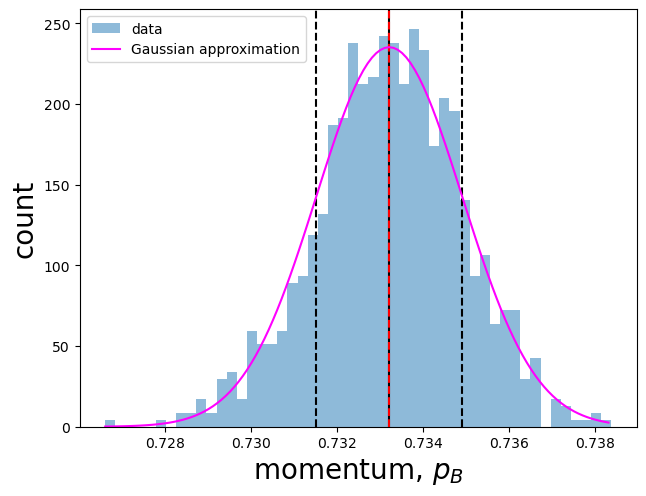

In [6]:

fig = plt.figure()
''' next, we create a axes canvas.  The 4 numbers represent
    ax = plt.axes([x0, y0, dx, dy])
    - x0: width from left to start canvas (in units of 0 - 1)
    - y0: height from bottome to start canvas
    - dx: width of canvas - NOTE, x0 + dx <= 1
    - dy: height of canvas - NOTE, y0 + dy <= 1
'''
ax    = plt.axes([0.12, 0.12, 0.87, 0.87])
''' Now let us plot the histogram
    - Nbins  : the number of bins to use
    - alpha  : a parameter taking the value [0, 1] that controls opacity
    - ;      : the semi-colon at the end prevents the function from printing
               values of the histogram - try removing it
    - density: it True, normalize so that int(hist) = 1

'''
Nbins = 50
ax.hist(q0s, bins=Nbins, alpha=.5, density=True, label='data');

# let us make some axis labels
ax.set_ylabel(r'count', fontsize=20);
ax.set_xlabel(r'momentum, $p_B$', fontsize=20);

# plot the mean value
ax.axvline(q0s.mean(), color='k')
# plot the standard deviation
ax.axvline(q0s.mean()-q0s.std(), color='k', linestyle='--')
ax.axvline(q0s.mean()+q0s.std(), color='k', linestyle='--')

# median
i_sort = q0s.argsort()
median = q0s[i_sort][len(q0s)//2]
ax.axvline(q0s.mean(), color='r', linestyle='--')

# plot Gaussian [normal] distrubution
''' If the data is "normally distributed", it will have the shape of a Gaussian
    see https://en.wikipedia.org/wiki/Normal_distribution

    prob(x) = Norm * exp( -(x - x_mean) / 2 / sigma**2)

    solve for Norm by

    1 = integral[-inf, inf] dx prob(x)

    Norm = 1 / sqrt(2 * pi * sigma**2)
'''
# create linespace
n_plot = 10000
x_min  = min(q0s)
x_max  = max(q0s)
x_plot = np.arange(x_min, x_max + (x_max-x_min)/n_plot, 1/n_plot)

def mom_dist(x, x_mean, x_sigma):
  Norm = 1 / np.sqrt( (2 * np.pi * x_sigma**2) )
  prob = Norm * np.exp( -(x - x_mean)**2 / 2 / x_sigma**2)

  return prob

gauss = mom_dist(x_plot, q0s.mean(), q0s.std())
ax.plot(x_plot, gauss, color='magenta', label='Gaussian approximation')

# plot our legend
ax.legend(loc=2)

Now we want to calculate and plot the unknown mass m_c.
Remember, the necessary equations and variables are in the slides!

In [ ]:
# Define missing_mass function

def missing_mass(mA, mB, q0s):
  # your code here


In [ ]:
# Plot the mass distribution histogram like we did above

# your code here